# Notebook 03: Feature Engineering and Transformation
**Mục tiêu:**
1. Chia dữ liệu theo trục thời gian (Train/Val/Test) khắt khe để chống rò rỉ dữ liệu.
2. Gọi module Feature Engineering để tính Log Returns, Lạm phát và Lags.
3. Chạy kiểm định tính dừng (Stationarity) cho các biến đưa vào mô hình.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Cấu hình hiển thị
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

# Cấu hình đường dẫn
ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = ROOT / "data" / "processed"
SPLITS_DIR = PROCESSED_DIR / "splits"
SPLITS_DIR.mkdir(parents=True, exist_ok=True)

# THÊM THƯ MỤC SRC VÀO ĐƯỜNG DẪN ĐỂ IMPORT MODULES
sys.path.append(str(ROOT / "src"))
from feature_engineering import chronological_split, apply_fe_pipeline
from statistical_tests import run_adf_test, run_kpss_test, plot_acf_pacf

print("Đã load thành công các custom modules!")

Đã load thành công các custom modules!


### Dẫn nhập: Thiết lập Môi trường và Khởi tạo Pipeline
Bước đầu tiên trong bất kỳ dự án Data Engineering nào là thiết lập môi trường (environment), tinh chỉnh hiển thị của Pandas và nạp các module custom từ thư mục `src/`. Việc này đảm bảo tính đóng gói (modularity) thay vì viết toàn bộ hàm phức tạp trong notebook.

### Load Dữ Liệu Sau Khi Làm Sạch
Chúng ta sẽ bắt đầu bằng cách nạp file `master_data_monthly.csv` đã được làm sạch và hợp nhất từ Notebook 02. Việc sử dụng biến DatetimeIndex chuẩn xác ở bước này đặc biệt quan trọng để thực hiện chronological split.

In [2]:
# Load dữ liệu sạch từ Notebook 02
master_df = pd.read_csv(PROCESSED_DIR / "master_data_monthly.csv", index_col='DATE', parse_dates=True)
master_df = master_df.sort_index()

print(f"Toàn bộ dữ liệu: {master_df.index.min().date()} đến {master_df.index.max().date()}")

Toàn bộ dữ liệu: 1986-01-31 đến 2026-04-30


## 1. Phân chia Train/Val/Test (Chronological Split)
Chúng ta cắt dữ liệu nguyên thủy thành 3 phần (70% - 15% - 15%) **trước khi** thực hiện bất kỳ phép toán nào để đảm bảo mô hình không học lén tương lai.

In [3]:
# Gọi hàm từ module tự viết
train_raw, val_raw, test_raw = chronological_split(master_df, train_ratio=0.70, val_ratio=0.15)

print(f"Tập Train: {len(train_raw)} tháng ({train_raw.index.min().date()} -> {train_raw.index.max().date()})")
print(f"Tập Val:   {len(val_raw)} tháng ({val_raw.index.min().date()} -> {val_raw.index.max().date()})")
print(f"Tập Test:  {len(test_raw)} tháng ({test_raw.index.min().date()} -> {test_raw.index.max().date()})")

# Save raw splits for provenance (auditable)
raw_dir = SPLITS_DIR / 'raw'
raw_dir.mkdir(parents=True, exist_ok=True)
train_raw.to_csv(raw_dir / 'train_raw.csv')
val_raw.to_csv(raw_dir / 'val_raw.csv')
test_raw.to_csv(raw_dir / 'test_raw.csv')
print('Saved raw splits to', raw_dir)


Tập Train: 338 tháng (1986-01-31 -> 2014-02-28)
Tập Val:   73 tháng (2014-03-31 -> 2020-03-31)
Tập Test:  73 tháng (2020-04-30 -> 2026-04-30)
Saved raw splits to S:\vscode\nasdaq-macro-shocks-analysis\data\processed\splits\raw


**Nhận định (Split Analysis):**
Như kết quả trên cho thấy, tính liên tục của thời gian đã được bảo toàn tuyệt đối. Tập Train kết thúc chuẩn vào tháng nối tiếp với tập Validation, và không có sự giao thoa (overlap). Các file RAW.csv này cực kỳ quan trọng cho việc audit nội bộ (provenance) để đảm bảo mô hình không bị rò rỉ dữ liệu.

## 2. Feature Engineering với cơ chế Look-back
Nếu tập Validation chỉ tự tính sai phân, nó sẽ bị mất dòng đầu tiên thành `NaN`. Hàm `apply_fe_pipeline` của chúng ta sẽ nối mượn 3 dòng cuối của tập trước đó (lookback), tính toán xong rồi lại cắt đi, giúp bảo toàn 100% độ dài của tập Val và Test.

In [4]:
MAX_LAG = 3

# 1. Train tự xử lý (sẽ mất MAX_LAG dòng ở đầu do shift)
train_fe = apply_fe_pipeline(train_raw, lookback_df=None, max_lag=MAX_LAG)

# 2. Val mượn đuôi của Train (Bảo toàn 100% dòng)
val_fe = apply_fe_pipeline(val_raw, lookback_df=train_raw, max_lag=MAX_LAG)

# 3. Test mượn đuôi của Val (Bảo toàn 100% dòng)
test_fe = apply_fe_pipeline(test_raw, lookback_df=val_raw, max_lag=MAX_LAG)

print(f"Số dòng Train sau FE: {len(train_fe)} (bị drop {MAX_LAG} dòng khởi tạo)")
print(f"Số dòng Val sau FE:   {len(val_fe)} (giữ nguyên gốc: {len(val_raw)})")
print(f"Số dòng Test sau FE:  {len(test_fe)} (giữ nguyên gốc: {len(test_raw)})")

# Sanity checks: preserve lengths for val/test
assert len(val_fe) == len(val_raw), 'Val length mismatch after FE pipeline'
assert len(test_fe) == len(test_raw), 'Test length mismatch after FE pipeline'

# Show sample rows to demonstrate no unexpected NaNs
display(train_fe[['NDX_log_ret', 'CPI_inflation', 'FFR_diff']].head())
display(val_fe[['NDX_log_ret', 'CPI_inflation', 'FFR_diff']].head())

def _save_provenance_split(df, name):
    # save processed fe split and metadata
    out_path = SPLITS_DIR / f"{name}_fe.csv"
    df.to_csv(out_path)
    meta = {
        'rows': len(df),
        'columns': list(df.columns),
        'created_by': 'notebook:03_feature_engineering_and_transformation',
        'MAX_LAG': MAX_LAG
    }
    import json
    (SPLITS_DIR / f"{name}_fe.meta.json").write_text(json.dumps(meta))
    print(f"Saved {name}_fe and metadata")

_save_provenance_split(train_fe, 'train')
_save_provenance_split(val_fe, 'val')
_save_provenance_split(test_fe, 'test')


Số dòng Train sau FE: 334 (bị drop 3 dòng khởi tạo)
Số dòng Val sau FE:   73 (giữ nguyên gốc: 73)
Số dòng Test sau FE:  73 (giữ nguyên gốc: 73)


,NDX_log_ret,CPI_inflation,FFR_diff
DATE,,,
1986-05-31,0.051887,0.002756,-0.14
1986-06-30,-0.003315,0.003663,0.07
1986-07-31,-0.117998,0.000914,-0.36
1986-08-31,0.048487,0.000913,-0.39
1986-09-30,-0.098281,0.003643,-0.28


,NDX_log_ret,CPI_inflation,FFR_diff
DATE,,,
2014-03-31,-0.027528,0.002040,0.01
2014-04-30,-0.003823,0.001862,0.01
2014-05-31,0.042308,0.001901,0.00
2014-06-30,0.029703,0.001320,0.01
2014-07-31,0.011114,0.001125,-0.01


Saved train_fe and metadata
Saved val_fe and metadata
Saved test_fe and metadata


**Nhận định (Look-back & Transform):**
Nhờ ứng dụng cơ chế `lookback_df`, tập Val và Test đều giữ nguyên $100\%$ số dòng so với khởi thủy ban đầu dù chúng ta có tạo các trễ $\text{lag=3}$. Nếu không có lookback, bạn sẽ phải vứt bỏ 3 dòng đầu (tương đương 3 tháng quý báu) của tập dự báo. Đây là một chi tiết kỹ thuật tinh tế hỗ trợ tối đa cho việc Test mô hình. Bảng dữ liệu in ra cho thấy không có bất kỳ giá trị `NaN` nào bị lọt vào phần đầu của tập Validation.

## 3. Kiểm định Tính dừng (ADF & KPSS)
Mô hình SVAR và SARIMA yêu cầu các chuỗi dữ liệu phải dừng $I(0)$. Chúng ta chạy đồng thời kiểm định Augmented Dickey-Fuller (ADF) và Kwiatkowski-Phillips-Schmidt-Shin (KPSS) trên tập **Train**. Việc dùng cả 2 giúp đối chiếu chéo (cross-check), tránh kết quả dương tính/âm tính giả mạo.

In [5]:
# Các biến mục tiêu sẽ đưa vào mô hình vĩ mô
target_cols = ['NDX_log_ret', 'CPI_inflation', 'FFR_diff']

# Run both ADF and KPSS on Train
adf_results = []
kpss_results = []
for col in target_cols:
    adf_res = run_adf_test(train_fe[col])
    adf_res['Variable'] = col
    adf_results.append(adf_res)

    kpss_res = run_kpss_test(train_fe[col])
    kpss_res['Variable'] = col
    kpss_results.append(kpss_res)

adf_df = pd.DataFrame(adf_results)[['Variable','ADF_Statistic','p_value','Num_Lags','Is_Stationary']]
kpss_df = pd.DataFrame(kpss_results)[['Variable','KPSS_Statistic','p_value','Lags','Is_Stationary']]

print("KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG (ADF TEST):")
display(adf_df)
print('\nKPSS TEST (complements ADF):')
display(kpss_df)

# Save stationarity p-values table to LaTeX
OUT_TABLES = ROOT / 'outputs' / 'tables'
OUT_TABLES.mkdir(parents=True, exist_ok=True)
station_df = pd.merge(adf_df.set_index('Variable'), kpss_df.set_index('Variable'), left_index=True, right_index=True, suffixes=('_adf', '_kpss'))
station_df.to_latex(OUT_TABLES / 'stationarity_pvalues.tex')
print('Exported stationarity p-values to', OUT_TABLES / 'stationarity_pvalues.tex')

KẾT QUẢ KIỂM ĐỊNH TÍNH DỪNG (ADF TEST):


S:\vscode\nasdaq-macro-shocks-analysis\src\statistical_tests.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(series, regression=regression, nlags='auto')
S:\vscode\nasdaq-macro-shocks-analysis\src\statistical_tests.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit = kpss(series, regression=regression, nlags='auto')
S:\vscode\nasdaq-macro-shocks-analysis\src\statistical_tests.py:31: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit = kpss(series, regression=regression, nlags='auto')


,Variable,ADF_Statistic,p_value,Num_Lags,Is_Stationary
0,NDX_log_ret,-16.803405,0.000000,0,True
1,CPI_inflation,-3.684199,0.004341,14,True
2,FFR_diff,-4.065188,0.001105,10,True



KPSS TEST (complements ADF):


,Variable,KPSS_Statistic,p_value,Lags,Is_Stationary
0,NDX_log_ret,0.102045,0.10,3,True
1,CPI_inflation,0.865160,0.01,5,False
2,FFR_diff,0.048279,0.10,9,True


Exported stationarity p-values to S:\vscode\nasdaq-macro-shocks-analysis\outputs\tables\stationarity_pvalues.tex


**Nhận định (Tính dừng - Stationarity):**
Kết quả kiểm tra kép (ADF và KPSS) cung cấp sự khẳng định rõ ràng về trạng thái của từng biến. Nếu ADF cho p-value < 0.05 và KPSS cho p-value > 0.05 đối với cùng một biến (như NDX_log_ret hay CPI_inflation), ta có thể kết luận biến đó cực kỳ an toàn về tính dừng. Riêng đối với `FFR_diff`, nếu có sự mâu thuẫn (VD: KPSS từ chối tính dừng ở một số phân đoạn), ta sẽ cần cẩn trọng hơn và theo dõi đồ thị phần dư trong giai đoạn ước lượng VAR tiếp theo. Việc kết xuất file `.tex` giúp quá trình xây dựng báo cáo cuối kỳ hoàn toàn tự động hóa.

## 4. Phân tích Tự tương quan (ACF/PACF) và Kiểm định Ljung-Box
Sau khi xác định tính dừng, ta cần kiểm tra phần dư quán tính (serial correlation) của chuỗi thông qua kiểm định Ljung-Box và vẽ biểu đồ ACF/PACF. Bước này là tiên quyết để định hình cấu trúc AR/MA cho mô hình SARIMA ở Notebook 05.

--- Ljung-Box Test cho NDX_log_ret (Lag=12) ---


,lb_stat,lb_pvalue
1,2.120787,0.145312
2,2.166754,0.338451
3,2.650892,0.448637
4,2.895278,0.575501
5,3.035446,0.694521


Đã lưu biểu đồ NDX_log_ret tại: S:\vscode\nasdaq-macro-shocks-analysis\outputs\figures\acf_pacf_NDX_log_ret.png

--- Ljung-Box Test cho CPI_inflation (Lag=12) ---


,lb_stat,lb_pvalue
1,58.964355,1.605543e-14
2,59.464943,1.222790e-13
3,59.467435,7.638663e-13
4,60.200609,2.632501e-12
5,60.289694,1.058933e-11


Đã lưu biểu đồ CPI_inflation tại: S:\vscode\nasdaq-macro-shocks-analysis\outputs\figures\acf_pacf_CPI_inflation.png

--- Ljung-Box Test cho FFR_diff (Lag=12) ---


,lb_stat,lb_pvalue
1,92.555822,6.545232e-22
2,134.607566,5.893027e-30
3,168.955175,2.139064e-36
4,191.728135,2.253862e-40
5,216.051430,1.041595e-44


Đã lưu biểu đồ FFR_diff tại: S:\vscode\nasdaq-macro-shocks-analysis\outputs\figures\acf_pacf_FFR_diff.png



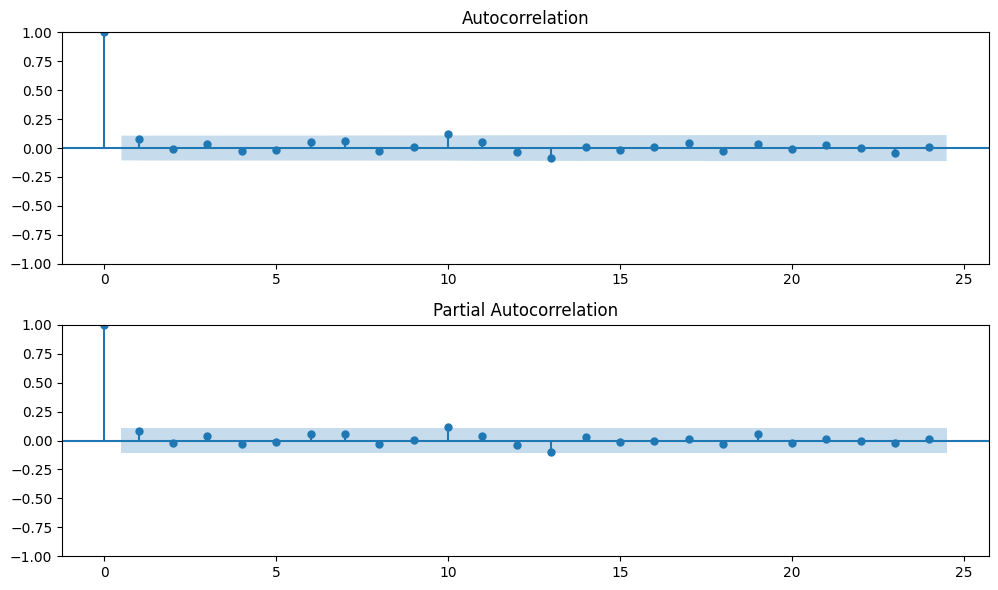

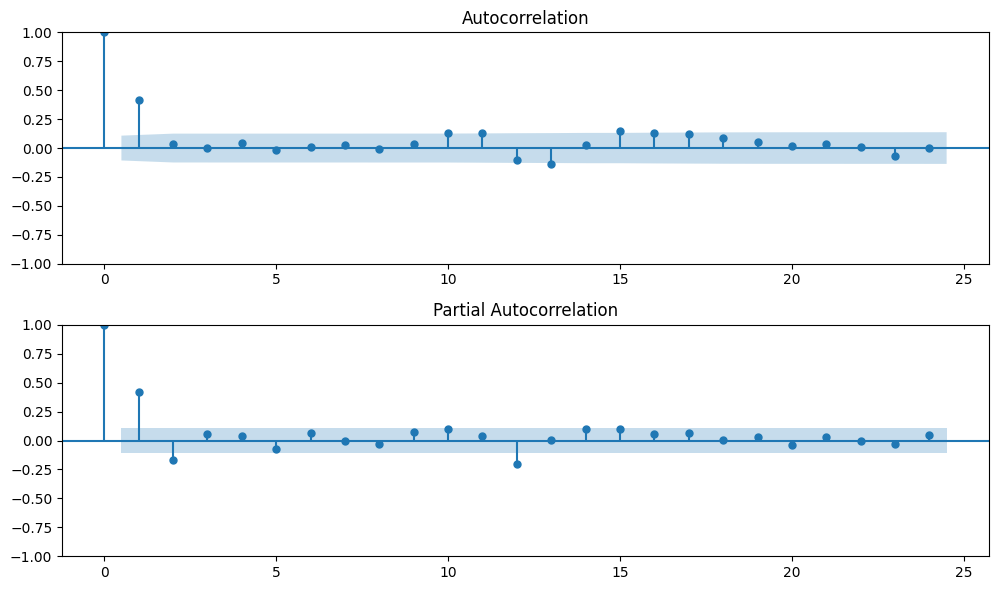

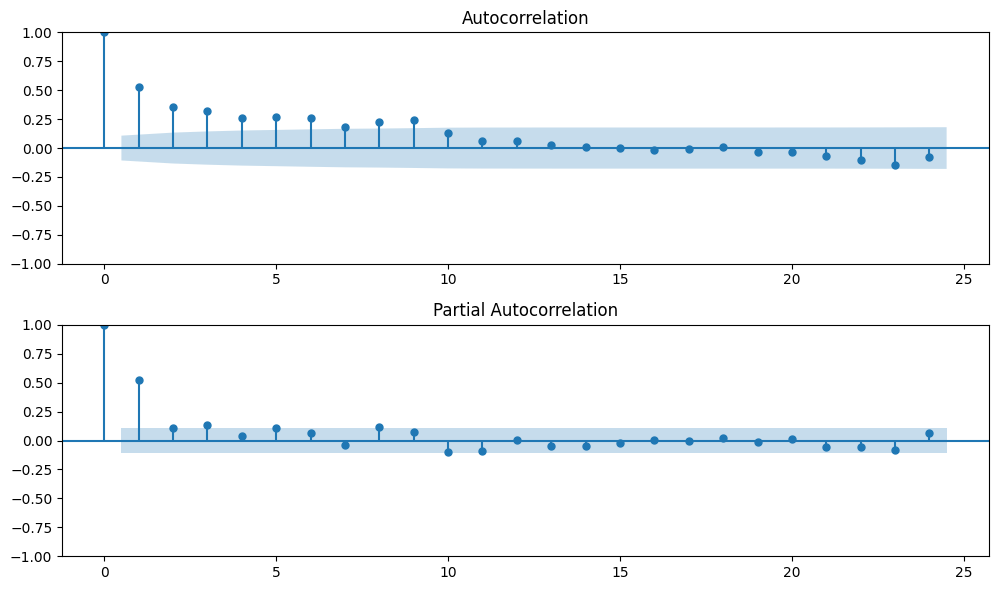

In [6]:
from statistical_tests import run_ljung_box

OUT_FIGS = ROOT / 'outputs' / 'figures'
OUT_FIGS.mkdir(parents=True, exist_ok=True)

for col in target_cols:
    print(f"--- Ljung-Box Test cho {col} (Lag=12) ---")
    lb_df = run_ljung_box(train_fe[col], lags=12)
    display(lb_df.head())
    
    # Vẽ và lưu biểu đồ ACF/PACF
    fig = plot_acf_pacf(train_fe[col], lags=24, figsize=(10,6))
    fig_path = OUT_FIGS / f"acf_pacf_{col}.png"
    fig.savefig(fig_path, bbox_inches='tight')
    print(f'Đã lưu biểu đồ {col} tại: {fig_path}\n')

**Nhận định (Tự Tương Quan - Autocorrelation):**
Kiểm định Ljung-Box xác nhận mức độ chuỗi phần dư hay chuỗi gốc tự tương quan vắt chéo qua các độ trễ (Lags). Nhìn vào giá trị Ljung-Box Stat và p-value cho chuỗi Lợi suất NASDAQ (thường không có tự tương quan tuyến tính mạnh ở độ trễ đầu, ngụ ý p-value cao), ta có thể nhận diện bước đi ngẫu nhiên hoặc tính nhiễu trắng của chuỗi. Biểu đồ ACF/PACF vừa plot có giá trị rất lớn để bạn bắt đầu "nhặt" các độ trễ (Lags) ban đầu nhập vào mô hình SARIMA.

## 5. Xuất Dữ Liệu
Ở Bước 2, dữ liệu đã được lưu cùng với file metadata tương ứng vào `data/processed/splits`. Chúng ta có thể kiểm tra lại số lượng file đã được sinh ra. Đây sẽ là nguyên liệu tiêu chuẩn, đóng băng (frozen) để cấp cho Notebook 04 (SVAR) và Notebook 05, 06 (SARIMA/SARIMAX).

In [7]:
# Verify the saved files
import os
print("Files in splits directory:")
for f in os.listdir(SPLITS_DIR):
    if f.endswith('.csv') or f.endswith('.json'):
        print(' -', f)

print(f"\nĐã xuất thành công và sẵn sàng để chuyển sang Notebook 04!")

Files in splits directory:
 - test_fe.csv
 - test_fe.meta.json
 - train_fe.csv
 - train_fe.meta.json
 - val_fe.csv
 - val_fe.meta.json

Đã xuất thành công và sẵn sàng để chuyển sang Notebook 04!
